In [ ]:
!pip install sentence-transformers
!pip install datasets

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Libraries import

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from bs4 import BeautifulSoup

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import LabelEncoder

import torch
from transformers import (DistilBertTokenizerFast,
                          DistilBertForSequenceClassification,
                          Trainer, TrainingArguments)

from collections import defaultdict
from tqdm.auto import tqdm

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Load and explore dataset


In [6]:
df = pd.read_csv('IMDB Dataset.csv')  # Replace with your Dataset file path

print("First 5 rows of the dataset:")
display(df.head())
print("\nDataset shape:", df.shape)
print("\nData types:\n", df.dtypes)

First 5 rows of the dataset:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Dataset shape: (50000, 2)

Data types:
 review       object
sentiment    object
dtype: object


# Data cleaning



In [7]:
df.replace('?', np.nan, inplace=True)
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 review       0
sentiment    0
dtype: int64


# Visualizations


<ipython-input-8-6119e85090b9>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


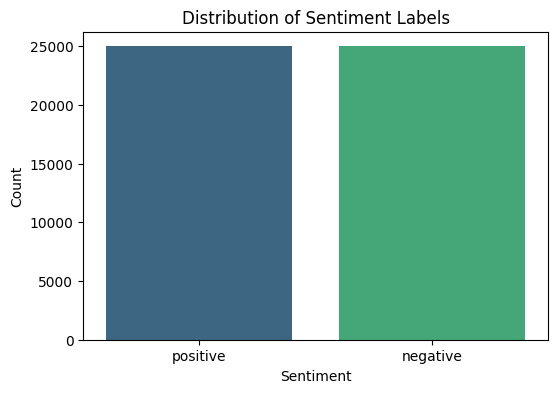

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

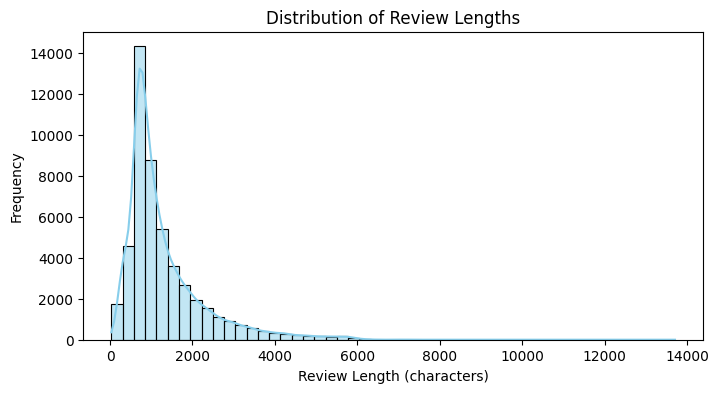

In [9]:
df['review_length'] = df['review'].apply(len)
plt.figure(figsize=(8,4))
sns.histplot(df['review_length'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (characters)")
plt.ylabel("Frequency")
plt.show()

# Text preprocessing


In [12]:
def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in stemmed_tokens]

    return " ".join(lemmatized_tokens)


In [14]:
df['clean_review'] = df['review'].apply(clean_text)
df.dropna(subset=['clean_review'], inplace=True)
df.drop_duplicates(subset=['clean_review'], inplace=True)
print("\nDataset shape after cleaning:", df.shape)


Dataset shape after cleaning: (49573, 4)


# Label encoding


In [15]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label mapping: {'negative': 0, 'positive': 1}


# Train-test split


In [16]:
X = df['clean_review']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 39658
Testing samples: 9915


# Feature engineering


In [17]:
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [18]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [19]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [20]:
X_train_embed = embedder.encode(X_train.tolist(), show_progress_bar=True, batch_size=32)

Batches:   0%|          | 0/1240 [00:00<?, ?it/s]

In [21]:
X_test_embed = embedder.encode(X_test.tolist(), show_progress_bar=True, batch_size=32)

Batches:   0%|          | 0/310 [00:00<?, ?it/s]

# Model training and evaluation

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Multinomial NB": MultinomialNB(),
    "Neural networks": MLPClassifier(random_state=42),
}

embedding_data = [
    ("Bag-of-Words", X_train_bow, X_test_bow),
    ("TF-IDF", X_train_tfidf, X_test_tfidf),
    ("Sentence Embedding", X_train_embed, X_test_embed)
]

results = defaultdict(dict)

In [24]:
for emb_name, X_tr, X_te in embedding_data:
    print(f"\n{'-'*40}\nEvaluating {emb_name} features\n{'-'*40}")
    for model_name, model in models.items():
        if emb_name == "Sentence Embedding" and model_name == "Multinomial NB":
            model = GaussianNB()
            model_name = "Gaussian NB"

        print(f"\nTraining {model_name}...")
        cv_results = cross_validate(model, X_tr, y_train, cv=5,
                                   scoring='accuracy', return_train_score=True)
        model.fit(X_tr, y_train)

        # Get predictions and probabilities
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

        # Store results
        results[emb_name][model_name] = {
            "cv_mean": np.mean(cv_results['test_score']),
            "cv_std": np.std(cv_results['test_score']),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "report": classification_report(y_test, y_pred, output_dict=True),
            "cm": confusion_matrix(y_test, y_pred),
            "y_proba": y_proba,
            "y_pred": y_pred
        }



----------------------------------------
Evaluating Bag-of-Words features
----------------------------------------

Training Logistic Regression...

Training Multinomial NB...

Training Neural networks...

----------------------------------------
Evaluating TF-IDF features
----------------------------------------

Training Logistic Regression...

Training Multinomial NB...

Training Neural networks...

----------------------------------------
Evaluating Sentence Embedding features
----------------------------------------

Training Logistic Regression...

Training Gaussian NB...

Training Neural networks...


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

# Transformer Model

In [31]:
from datasets import Dataset, DatasetDict

In [33]:
df_train = pd.DataFrame({'text': X_train, 'label': y_train})
df_test = pd.DataFrame({'text': X_test, 'label': y_test})

dataset_dict = DatasetDict({
    'train': Dataset.from_pandas(df_train),
    'test': Dataset.from_pandas(df_test)
})

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [34]:
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=256)

In [35]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["__index_level_0__", "text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

Map:   0%|          | 0/39658 [00:00<?, ? examples/s]

Map:   0%|          | 0/9915 [00:00<?, ? examples/s]

In [36]:
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [37]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="steps",
    eval_steps=500,
    logging_steps=100,
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [38]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [39]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)


In [ ]:
print("\nTraining Transformer model...")
trainer.train()

In [ ]:
# Add transformer to results
test_pred = trainer.predict(tokenized_datasets["test"])
transformer_probs = torch.nn.functional.softmax(torch.Tensor(test_pred.predictions), dim=1).numpy()

results["Transformer"] = {
    "DistilBERT": {
        "test_accuracy": accuracy_score(y_test, np.argmax(test_pred.predictions, axis=1)),
        "report": classification_report(y_test, np.argmax(test_pred.predictions, axis=1), output_dict=True),
        "cm": confusion_matrix(y_test, np.argmax(test_pred.predictions, axis=1)),
        "y_proba": transformer_probs[:, 1],
        "y_pred": np.argmax(test_pred.predictions, axis=1)
    }
}

# Visualization functions


In [25]:
def plot_confusion_matrix(cm, classes, model_name, emb_name):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {model_name} ({emb_name})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def plot_classification_report(report, model_name, emb_name):
    # Convert the report to a DataFrame and process it
    df_report = pd.DataFrame(report).transpose().drop('support', axis=1, errors='ignore')
    df_report = df_report.reset_index().rename(columns={'index': 'Class'})  # Include class names as a column

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')  # Hide axes

    # Create table
    table = ax.table(
        cellText=df_report.round(4).values,  # Rounded values for readability
        colLabels=df_report.columns,         # Column headers
        cellLoc='center',                    # Center-align text
        loc='center'                         # Table location
    )

    # Style adjustments
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)  # Scale cell sizes

    plt.title(f'Classification Report - {model_name} ({emb_name})')
    plt.show()


def plot_roc_curves(results, y_true):
    plt.figure(figsize=(10,8))
    for emb_name in results:
        for model_name in results[emb_name]:
            model_data = results[emb_name][model_name]
            if model_data["y_proba"] is not None:
                fpr, tpr, _ = roc_curve(y_true, model_data["y_proba"])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, lw=2,
                        label=f'{model_name} ({emb_name}) AUC = {roc_auc:.2f}')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend(loc="lower right")
    plt.show()


# Generate all visualizations



Generating visualizations...


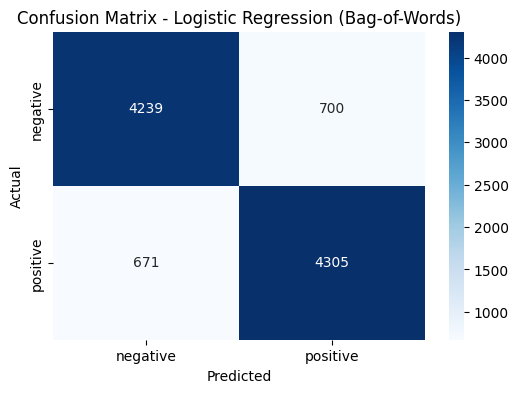

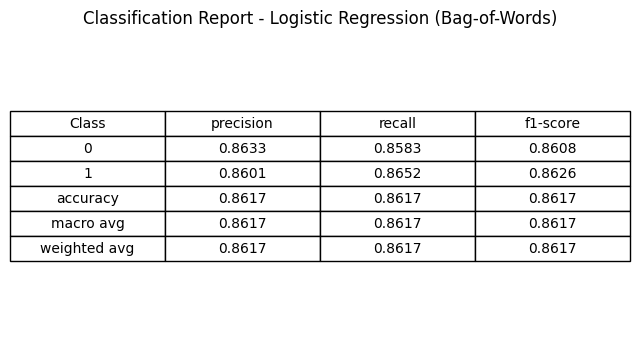

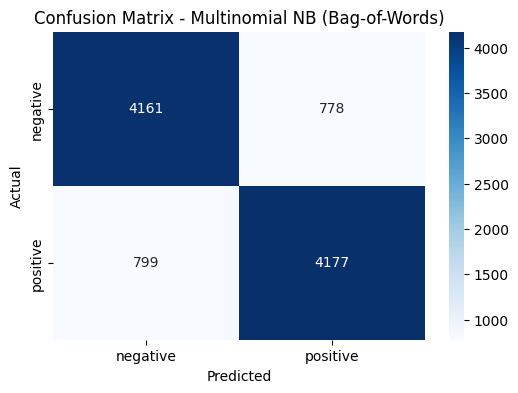

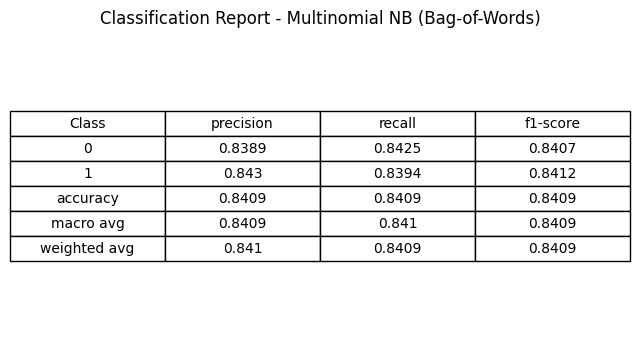

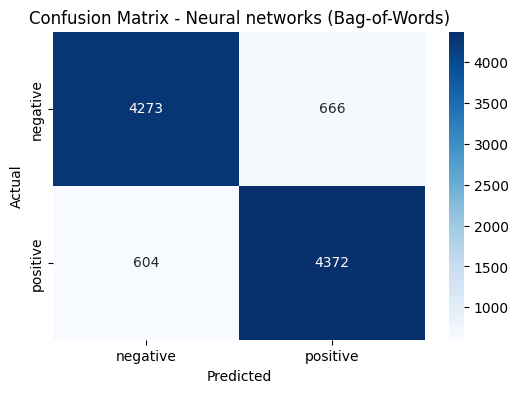

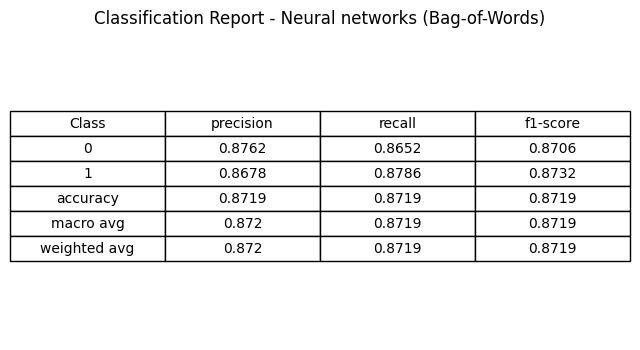

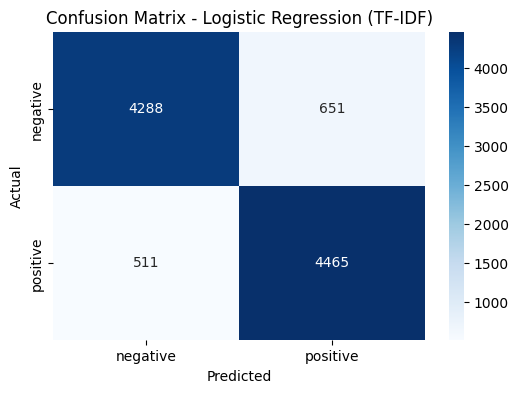

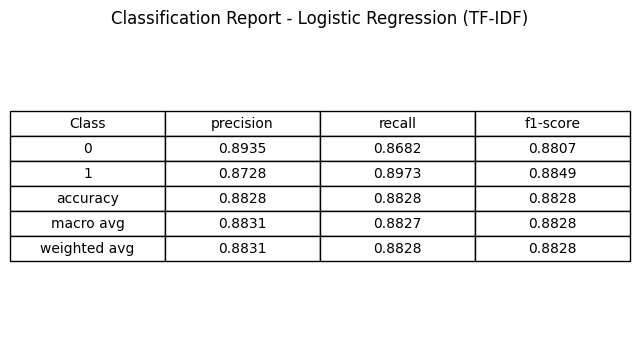

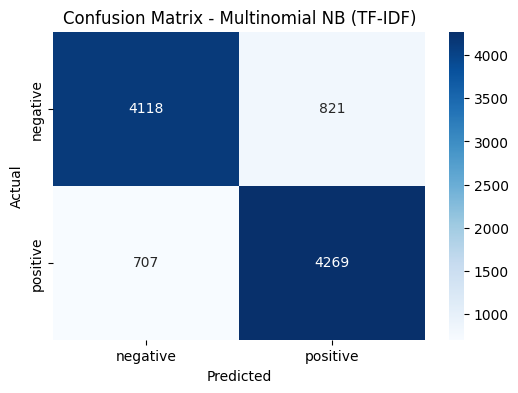

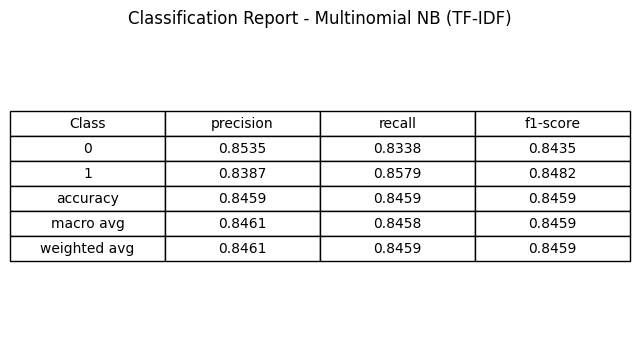

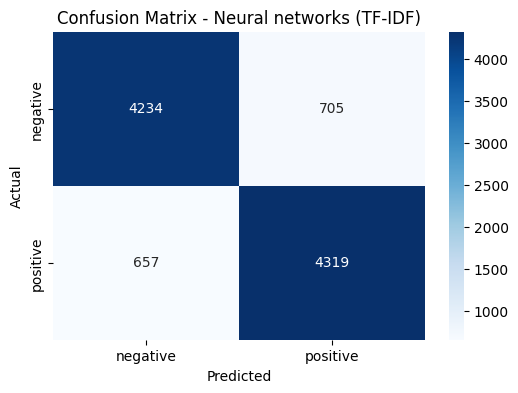

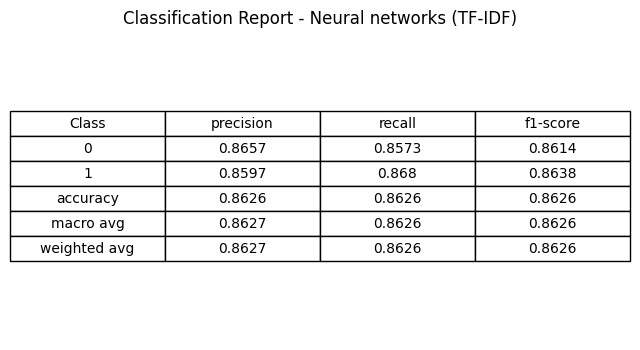

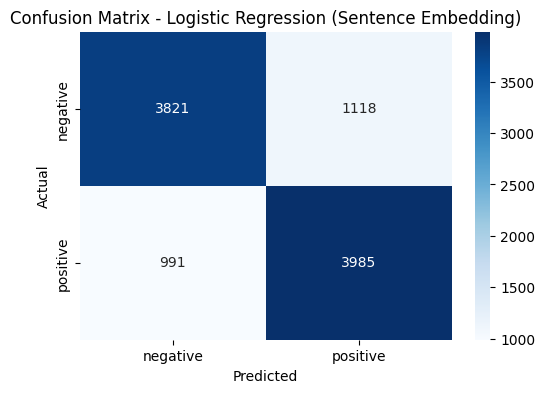

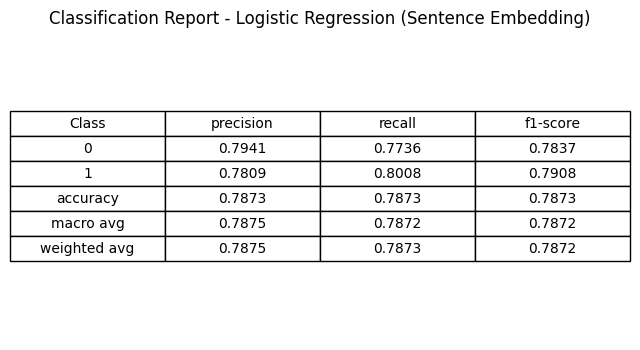

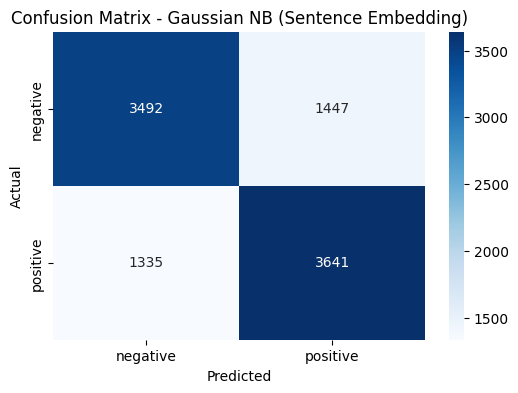

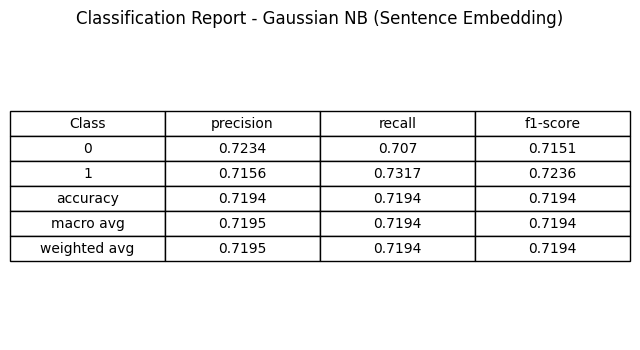

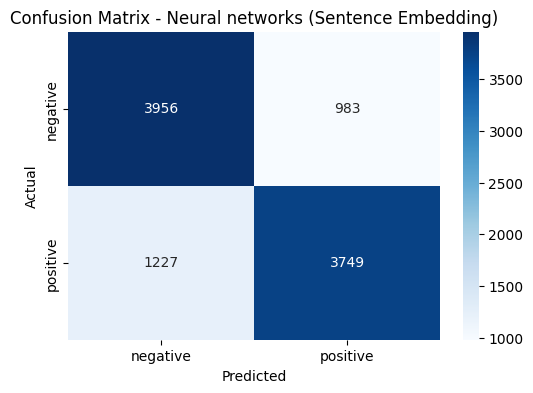

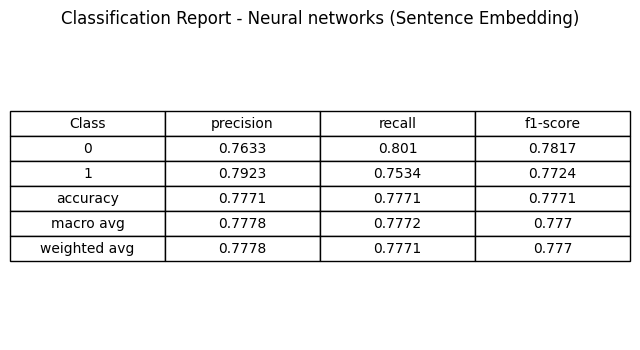

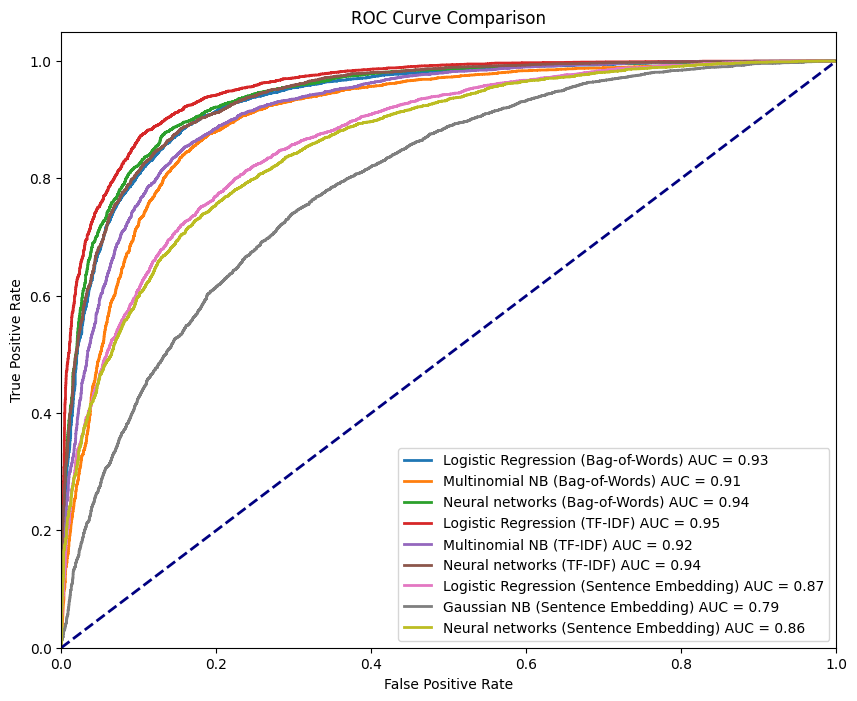

In [26]:
class_names = label_encoder.classes_

print("\nGenerating visualizations...")
for emb_name in results:
    for model_name in results[emb_name]:
        model_data = results[emb_name][model_name]
        plot_confusion_matrix(model_data["cm"], class_names, model_name, emb_name)
        plot_classification_report(model_data["report"], model_name, emb_name)

plot_roc_curves(results, y_test)

print()


# Accuracy comparison


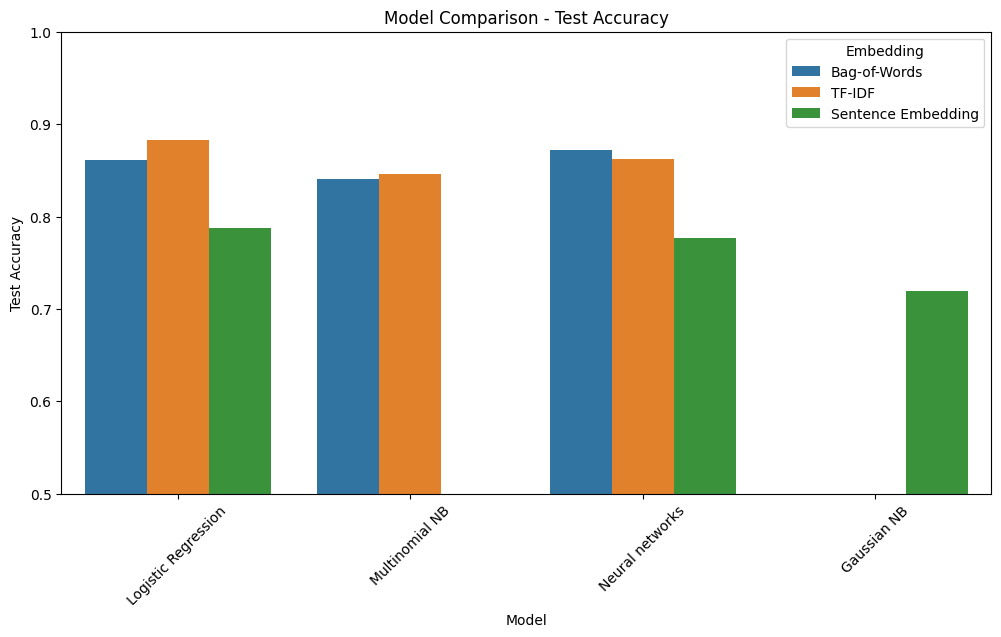


Final Test Accuracies:
            Embedding                Model  Test Accuracy
3              TF-IDF  Logistic Regression       0.882804
2        Bag-of-Words      Neural networks       0.871911
5              TF-IDF      Neural networks       0.862632
0        Bag-of-Words  Logistic Regression       0.861725
4              TF-IDF       Multinomial NB       0.845890
1        Bag-of-Words       Multinomial NB       0.840948
6  Sentence Embedding  Logistic Regression       0.787292
8  Sentence Embedding      Neural networks       0.777105
7  Sentence Embedding          Gaussian NB       0.719415


In [27]:
acc_data = []
for emb_name in results:
    for model_name in results[emb_name]:
        acc_data.append({
            "Embedding": emb_name,
            "Model": model_name,
            "Test Accuracy": results[emb_name][model_name]["test_accuracy"]
        })

df_acc = pd.DataFrame(acc_data)

plt.figure(figsize=(12,6))
sns.barplot(data=df_acc, x="Model", y="Test Accuracy", hue="Embedding")
plt.title("Model Comparison - Test Accuracy")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45)
plt.show()

print("\nFinal Test Accuracies:")
print(df_acc.sort_values(by="Test Accuracy", ascending=False))